In [34]:
import time
import random
import matplotlib.pyplot as plt

In [35]:
def current_milli_time():
	return round(time.time() * 1000)

In [36]:
def average_time(func, arg, repeats=3):
	total = 0
	for _ in range(repeats):
		total += func(arg)
	return total / repeats

### Добавление в конец списка

In [37]:
def test_append_end(n):
	a = []
	start = current_milli_time()
	for _ in range(n):
		a.append(random.randint(1, 99))
	end = current_milli_time()
	return end - start

In [38]:
sizes=[1000, 10000, 100000, 1000000]
times=[]
for size in sizes:
	avg=average_time(test_append_end, size)
	times.append(avg)
	print(f"Добавление в конец списка для {size} элементов: {avg:.2f} мс")

Добавление в конец списка для 1000 элементов: 0.33 мс
Добавление в конец списка для 10000 элементов: 5.33 мс
Добавление в конец списка для 100000 элементов: 46.67 мс
Добавление в конец списка для 1000000 элементов: 379.67 мс


Сложность: O(1)

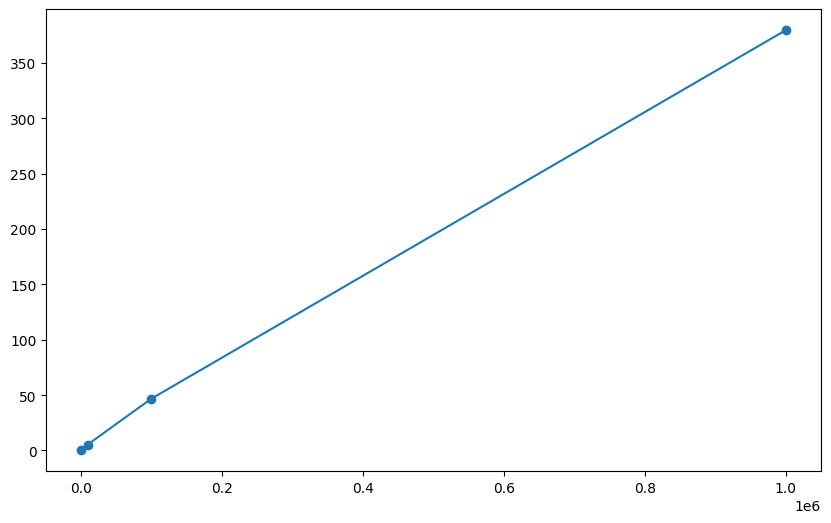

In [39]:
plt.figure(figsize=(10, 6))
plt.plot(sizes, times, 'o-')

### Добавление в начало списка

In [40]:
def test_insert_start(n):
	a = []
	start = current_milli_time()
	for _ in range(n):
		a.insert(0, random.randint(1, 99))
	end = current_milli_time()
	return end - start

In [41]:
sizes=[1000, 10000, 100000, 1000000]
times=[]
for size in sizes:
	avg=average_time(test_insert_start, size)
	times.append(avg)
	print(f"Добавление в началов списка для {size} элементов: {avg:.2f} мс")

Добавление в началов списка для 1000 элементов: 1.00 мс
Добавление в началов списка для 10000 элементов: 14.00 мс
Добавление в началов списка для 100000 элементов: 1137.67 мс
Добавление в началов списка для 1000000 элементов: 126830.33 мс


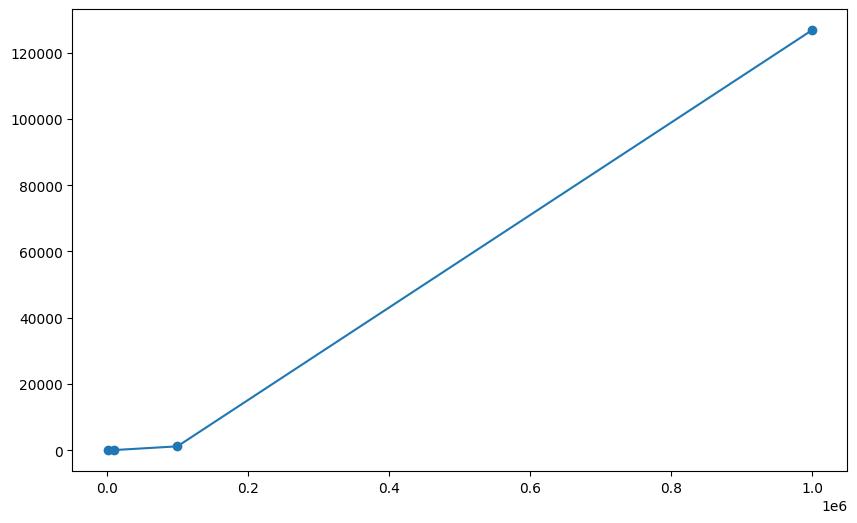

In [42]:
plt.figure(figsize=(10, 6))
plt.plot(sizes, times, 'o-')

Сложность: O(n)

### Пузырьковая сортировка

In [43]:
def bubble_sort(arr):
	n = len(arr)
	for i in range(n):
		for j in range(0, n - i - 1):
			if arr[j] > arr[j + 1]:
				arr[j], arr[j + 1] = arr[j + 1], arr[j]

In [44]:
def test_bubble_sort(n=1000):
	arr = [random.randint(1, 1000) for _ in range(n)]
	start = current_milli_time()
	bubble_sort(arr)
	end = current_milli_time()
	return end - start

In [45]:
sizes=[1000, 5000, 10000]
times=[]
for size in sizes:
	avg=average_time(test_bubble_sort, size)
	times.append(avg)
	print(f"Bubble Sort для {size} элементов: {avg:.2f} мс")

Bubble Sort для 1000 элементов: 43.33 мс
Bubble Sort для 5000 элементов: 1153.33 мс
Bubble Sort для 10000 элементов: 4811.00 мс


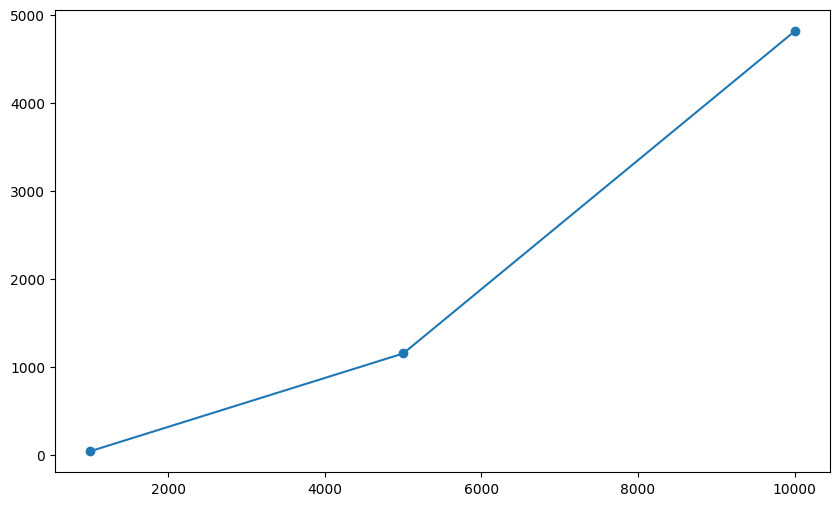

In [46]:
plt.figure(figsize=(10, 6))
plt.plot(sizes, times, 'o-')

Сложность: O(n²)

### Встроенная сортировка

In [49]:
def test_builtin_sort(n):
	arr = [random.randint(1, n) for _ in range(n)]
	start = current_milli_time()
	arr.sort()
	end = current_milli_time()
	return end - start


In [50]:
sizes=[1000, 10000, 100000, 1000000]
times=[]
for size in sizes:
	avg=average_time(test_builtin_sort, size)
	times.append(avg)
	print(f"Встроенная sort() для {size} элементов: {avg:.2f} мс")

Встроенная sort() для 1000 элементов: 0.00 мс
Встроенная sort() для 10000 элементов: 1.00 мс
Встроенная sort() для 100000 элементов: 14.00 мс
Встроенная sort() для 1000000 элементов: 221.00 мс


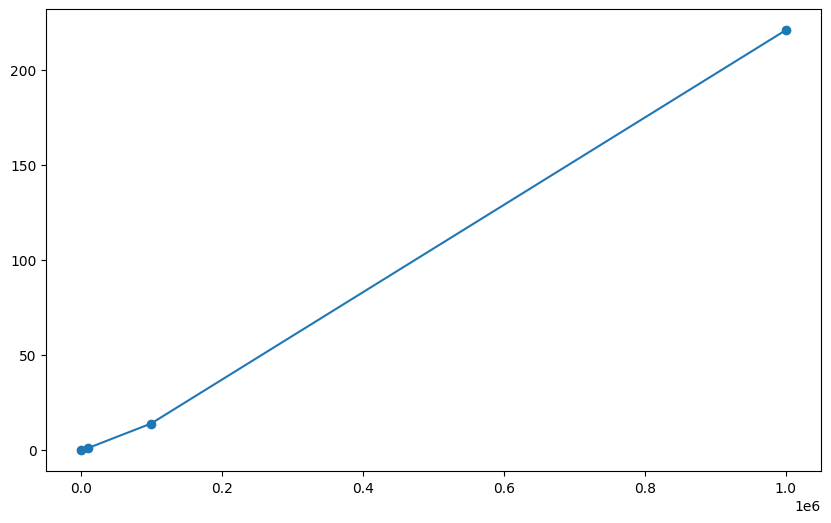

In [51]:
plt.figure(figsize=(10, 6))
plt.plot(sizes, times, 'o-')

Сложность: O(n*log n)

1. **Что такое временная сложность алгоритма, как её определить?**  
Временная сложность алгоритма показывает, как быстро растёт количество операций при увеличении объёма входных данных. Чтобы её определить, можно проанализировать код, учитывая вложенные циклы и рекурсивные вызовы или провести замеры времени работы на разных наборах данных и измерить зависимость времени от их размера.

2. **Какой способ оптимизации времени выполнения сортировки списка применён в задании №4?**  
В задании применяется стандартный метод `sort()`, работающий на основе алгоритма Timsort. Этот метод сочетает сортировку слиянием и вставками, обеспечивая эффективность O(n*logn), что значительно быстрее, чем O(n²) у простых алгоритмов вроде пузырьковой сортировки.

3. **Как можно оптимизировать добавление элементов в начало списка?**  
   Для частой вставки в начало лучше выбрать `collections.deque`, у которого есть метод `appendleft()` с константной сложностью O(1), либо хранить элементы в обратном порядке, добавляя их в конец (O(1)), а затем при необходимости разворачивать список.